Found Nk=3969 k-points; Nb=20 bands
After folding/dedup: 3969 → 3969 unique k-points
Gap stats (eV): min = 0.0 max = 11.3399


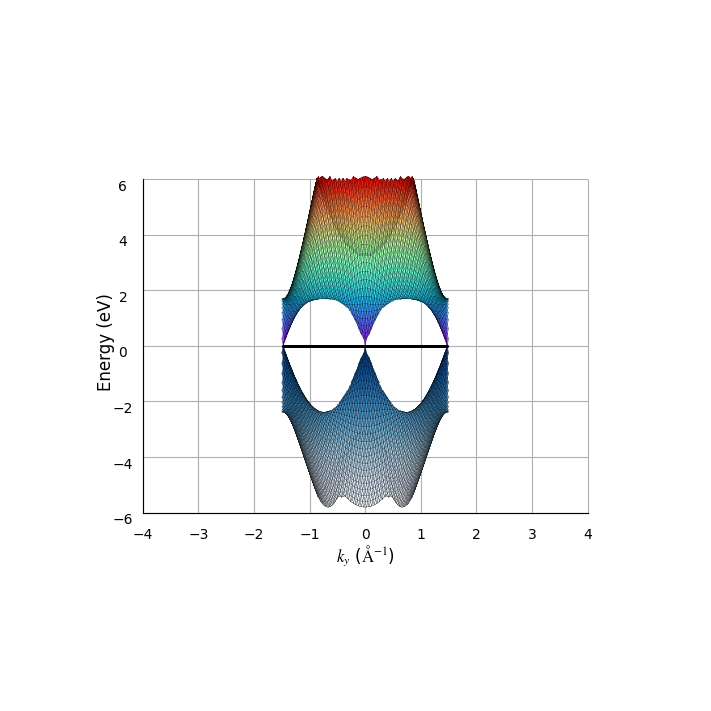


Nearest-gap check at the 6 BZ corners (using CENTRAL k_u set):
corner: [-1.70552216 -0.        ] nearest gap: 0.5148999999999999 dist: 0.04685697915357055
corner: [-0.85276108 -1.47702551] nearest gap: 0.5148999999999999 dist: 0.04678355437253245
corner: [ 0.85276108 -1.47702551] nearest gap: 0.0 dist: 0.00015329175668970748
corner: [1.70552216 0.        ] nearest gap: 0.5148999999999999 dist: 0.04685697915357055
corner: [0.85276108 1.47702551] nearest gap: 0.5148999999999999 dist: 0.04678355437253245
corner: [-0.85276108  1.47702551] nearest gap: 0.0 dist: 0.00015329175668970748


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import re
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["axes.labelsize"] = 12

# ===================== USER INPUT =====================
qe_nscf_file = "gr.nscf1.out"   # QE NSCF output file
alat_bohr    = 4.6412          # QE alat in Bohr
Ef           = -4.2071         # Fermi level (eV)
tile_search  = 2               # folding search range in reciprocal shifts
dedup_tol    = 1e-6            # Å^-1 rounding tolerance for dedup
view_elev    = 25              # view angle
view_azim    = 35              # view angle

# 1) READ QE FILE, EXTRACT k + ALL BAND ENERGIES
with open(qe_nscf_file, "r", errors="ignore") as f:
    lines = f.readlines()

num = r"[-+]?\d*\.?\d+(?:[EeDd][-+]?\d+)?"
k_header = re.compile(
    rf"^\s*k\s*=\s*({num})\s*({num})\s*({num})\s*\([^)]*PWs\)\s*bands\s*\(ev\)\s*:",
    re.IGNORECASE
)
num_pat = re.compile(num)

k_list = []
bands_list = []

i = 0
while i < len(lines):
    m = k_header.match(lines[i])
    if not m:
        i += 1
        continue

    kx, ky, kz = map(float, m.groups())

    j = i + 1
    energies = []
    while j < len(lines) and ("occupation numbers" not in lines[j].lower()) and (not k_header.match(lines[j])):
        energies += num_pat.findall(lines[j])
        j += 1

    e = list(map(float, energies))
    if len(e) > 0:
        k_list.append([kx, ky])
        bands_list.append(e)

    i = j

k_qe = np.array(k_list, float)            # QE units: 2π/alat
Ebands = np.array(bands_list, float)      # (Nk, Nb)
Nk, Nb = Ebands.shape
print(f"Found Nk={Nk} k-points; Nb={Nb} bands")

# 2) CONVERT k TO Å^-1
bohr_to_A = 0.529177
factor = (2.0 * np.pi / alat_bohr) / bohr_to_A
kx_A = k_qe[:, 0] * factor
ky_A = k_qe[:, 1] * factor

alat_A = alat_bohr * bohr_to_A
a = alat_A

b1 = (2*np.pi/a) * np.array([1.0, -1.0/np.sqrt(3.0)])
b2 = (2*np.pi/a) * np.array([0.0,  2.0/np.sqrt(3.0)])

V6 = np.array([
    (2*b1 + b2)/3,
    (b1 + 2*b2)/3,
    (b1 - b2)/3,
    -(2*b1 + b2)/3,
    -(b1 + 2*b2)/3,
    -(b1 - b2)/3,
])

angles = np.arctan2(V6[:, 1], V6[:, 0])
V6 = V6[np.argsort(angles)]
V = np.vstack([V6, V6[0]])

def point_in_poly(x, y, poly):
    inside = False
    x0, y0 = poly[0]
    for ii in range(1, len(poly) + 1):
        x1, y1 = poly[ii % len(poly)]
        if ((y0 > y) != (y1 > y)):
            xinters = (x1 - x0) * (y - y0) / (y1 - y0 + 1e-30) + x0
            if x < xinters:
                inside = not inside
        x0, y0 = x1, y1
    return inside

def fold_to_1BZ(kx_in, ky_in, b1, b2, hex_vertices, search=2):
    """
    Fold points into the 1st hex BZ by trying shifts m*b1+n*b2
    and selecting a candidate inside the polygon.
    """
    K = np.column_stack([kx_in, ky_in])
    Kf = np.zeros_like(K)

    shifts = []
    for m in range(-search, search + 1):
        for n in range(-search, search + 1):
            shifts.append(m*b1 + n*b2)
    shifts = np.array(shifts)

    for idx, kpt in enumerate(K):
        kcands = kpt - shifts
        mask = np.array([point_in_poly(p[0], p[1], hex_vertices) for p in kcands])
        if np.any(mask):
            ins = kcands[mask]
            # choose closest to Gamma (tie-break)
            j = np.argmin(np.sum(ins**2, axis=1))
            Kf[idx] = ins[j]
        else:
            # fallback: closest to Gamma among all candidates
            j = np.argmin(np.sum(kcands**2, axis=1))
            Kf[idx] = kcands[j]

    return Kf[:, 0], Kf[:, 1]

kx_fold, ky_fold = fold_to_1BZ(kx_A, ky_A, b1, b2, V6, search=tile_search)

# 4) DEDUPLICATE k AND AVERAGE BANDS (after folding)
tol = dedup_tol
kx_r = np.round(kx_fold / tol) * tol
ky_r = np.round(ky_fold / tol) * tol
keys = np.column_stack([kx_r, ky_r])

uniqK, inv = np.unique(keys, axis=0, return_inverse=True)
Nk_u = len(uniqK)

Ebands_u = np.zeros((Nk_u, Nb))
counts = np.zeros(Nk_u)

for i in range(Nk):
    g = inv[i]
    Ebands_u[g] += Ebands[i]
    counts[g] += 1

Ebands_u /= counts[:, None]
kx_u = uniqK[:, 0]
ky_u = uniqK[:, 1]

print(f"After folding/dedup: {Nk} → {Nk_u} unique k-points")

# 5) VALENCE / CONDUCTION AT EACH k (closest below/above Ef)
Eval = np.empty(Nk_u)
Econd = np.empty(Nk_u)

for i in range(Nk_u):
    e = Ebands_u[i]
    below = e[e <= Ef]
    above = e[e >= Ef]
    if len(below) == 0 or len(above) == 0:
        Eval[i] = np.nan
        Econd[i] = np.nan
    else:
        Eval[i]  = below.max()
        Econd[i] = above.min()

gap = Econd - Eval
print("Gap stats (eV): min =", np.nanmin(gap), "max =", np.nanmax(gap))

# shift by Ef for plotting
Eval_shift = Eval - Ef
Econd_shift = Econd - Ef

# 6) PERIODIC TILING FIX
shifts = [
    np.array([0.0, 0.0]),
    b1, -b1,
    b2, -b2,
    (b1 + b2), -(b1 + b2),
]

kx_tile = []
ky_tile = []
Eval_tile = []
Econd_tile = []

for s in shifts:
    kx_tile.append(kx_u + s[0])
    ky_tile.append(ky_u + s[1])
    Eval_tile.append(Eval_shift)
    Econd_tile.append(Econd_shift)

kx_tile = np.concatenate(kx_tile)
ky_tile = np.concatenate(ky_tile)
Eval_tile = np.concatenate(Eval_tile)
Econd_tile = np.concatenate(Econd_tile)

tri = mtri.Triangulation(kx_tile, ky_tile)

# mask triangles whose centroid lies outside the central hexagon
triangles = tri.triangles
cx = kx_tile[triangles].mean(axis=1)
cy = ky_tile[triangles].mean(axis=1)
mask = np.array([not point_in_poly(x, y, V6) for x, y in zip(cx, cy)])
tri.set_mask(mask)

# 7) PLOT: Valence + Conduction surfaces in central BZ
fig = plt.figure(figsize=(10, 7), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")

# surfaces
ax.plot_trisurf(tri, Eval_tile, cmap="Blues",   alpha=0.90,
                linewidth=0.15, edgecolor="k")
ax.plot_trisurf(tri, Econd_tile, cmap="rainbow", alpha=0.70,
                linewidth=0.15, edgecolor="k")
ax.plot(V[:, 0], V[:, 1], 0.0, color="k", lw=2)

ax.set_xlabel(r"$k_x$ ($\mathrm{\AA^{-1}}$)", labelpad=12)
ax.set_ylabel(r"$k_y$ ($\mathrm{\AA^{-1}}$)", labelpad=12)
ax.set_zlabel(r"$E - E_F$ (eV)", labelpad=14)

# axis limits
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_zlim(-6, 6)

# view
ax.view_init(elev=0, azim=0)
ax.set_proj_type('ortho')

ax.set_xlabel("")                 # remove label
ax.set_xticks([])                 # remove ticks
ax.xaxis.line.set_alpha(0)        # hide axis line
ax.xaxis.pane.set_alpha(0)        # hide pane wall
ax.xaxis._axinfo["grid"]["linewidth"] = 0  # hide grid lines for that axis
ax.set_zlabel("")
fig.text(0.25, 0.52, r"Energy (eV)", rotation="vertical",
         va="center", ha="center",fontsize=12)
# save with extra padding (also key!)
plt.savefig("graphene_bands_3D_DFT_project2.jpg", dpi=300, bbox_inches="tight", pad_inches=0.25)
plt.show()


print("\nNearest-gap check at the 6 BZ corners (using CENTRAL k_u set):")
for c in V6:
    dist = np.sqrt((kx_u - c[0])**2 + (ky_u - c[1])**2)
    ii = np.argmin(dist)
    print("corner:", c, "nearest gap:", gap[ii], "dist:", dist[ii])